# Notebook 05 - Deterministic 3D Pipe Autorouting

This lesson generates route candidates, reviews them interactively, and exports Code_Aster study files for downstream evaluation.

Important boundary: with `RUN_CODE_ASTER = False`, this notebook creates solver handoff files only. A routed pipe is not an engineering-approved result until Code_Aster has executed and Tuba has imported the result artifacts.

You will do five things:

1. Define obstacles inside a `Model`.
2. Configure a `PipeRouteRequest` with endpoints and constraints.
3. Generate and rank route candidates.
4. Visualize candidates interactively.
5. Review exported Code_Aster study files.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tuba import Model
from tuba.analysis.code_aster_notebook import configure_code_aster_notebook_runtime
from tuba.routing import AutoroutingAgent, GridRouter
from tuba.routing.solver_loop import SolverLoopConfig
from tuba.routing.types import (
    PipeRouteRequest,
    RouteEndpoint,
    RoutingConstraints,
    RoutingGridSpec,
)
from tuba.routing.visualization import build_route_plotter, export_route_scene_html

import pyvista as pv
# Defaults to zoomable embedded HTML locally; set TUBA_NOTEBOOK_BACKEND=client or static to override.
from tuba.plotting.notebook import configure_notebook_backend
JUPYTER_BACKEND = configure_notebook_backend()

## 1. Define the Scene

The autorouter operates on a standard `Model`. We add the usual material and
pipe section, then place **obstacle keepout volumes** — axis-aligned cuboids
that the router must steer around.

Think of obstacles as bounding boxes around equipment, cable trays, or
maintenance-access zones that the pipe cannot penetrate.


In [2]:
# ── Model, material & section ────────────────────────────────────────
model = Model("AutoroutingDemo")

model.add_material(
    "steel",
    E=210e9,
    nu=0.3,
    rho=7850,
    alpha=12e-6,
    allowable_stress={20.0: 140e6, 120.0: 125e6},
)

model.add_pipe_section("DN100", OD=0.1143, WT=0.00602)

# ── Load case ─────────────────────────────────────────────────────────
model.define_load_case("Hot", gravity=True, pressure=1e6, temperature=120.0)

# ── Obstacles ─────────────────────────────────────────────────────────
model.add_obstacle(
    id="equipment_box",
    type="cuboid",
    min_point=[1.5, -0.4, -0.4],
    max_point=[2.5,  0.4,  0.4],
)

model.add_obstacle(
    id="maintenance_keepout",
    type="cuboid",
    min_point=[2.8, 0.8, -0.4],
    max_point=[3.4, 1.4,  0.8],
)

print(f"Model '{model.project_name}' ready — {len(model.obstacles)} obstacles defined.")

Model 'AutoroutingDemo' ready — 2 obstacles defined.


## 2. Define the Route Request

A `PipeRouteRequest` tells the router *what* to connect:

| Field | Purpose |
|-------|---------|
| `start` / `goal` | `RouteEndpoint` — named 3D coordinates |
| `section` | Pipe section name (must exist in the model) |
| `material` | Material name (must exist in the model) |
| `constraints` | `RoutingConstraints` — clearance envelope around obstacles, minimum bend radius |


In [3]:
request = PipeRouteRequest(
    id="P-100",
    start=RouteEndpoint("A", (0.0, 0.0, 0.0)),
    goal=RouteEndpoint("B", (4.0, 0.0, 0.0)),
    section="DN100",
    material="steel",
    constraints=RoutingConstraints(
        clearance=0.10,
        min_bend_radius=0.20,
    ),
)

print(f"Route request '{request.id}':")
print(f"  Start  {request.start.id} → {request.start.point}")
print(f"  Goal   {request.goal.id} → {request.goal.point}")
print(f"  Clearance      = {request.constraints.clearance} m")
print(f"  Min bend radius = {request.constraints.min_bend_radius} m")

Route request 'P-100':
  Start  A → (0.0, 0.0, 0.0)
  Goal   B → (4.0, 0.0, 0.0)
  Clearance      = 0.1 m
  Min bend radius = 0.2 m


## 3. Optional Pre-Route Scene Check

Run this cell if you want to inspect endpoints and keepout volumes before routing. For the fastest path, skip directly to the autorouter cell and inspect the candidate result scene.


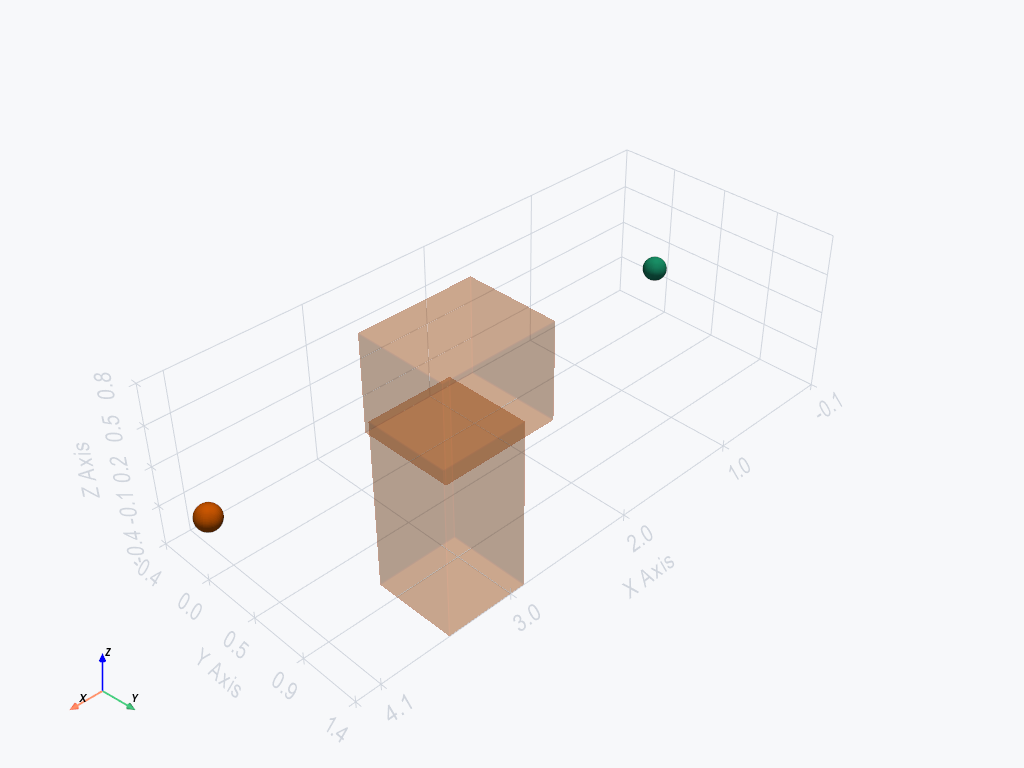

In [4]:
plotter = build_route_plotter(model, request=request)
plotter.show(jupyter_backend=JUPYTER_BACKEND)

## 4. Run the Autorouter and Export Solver Studies

`AutoroutingAgent` combines routing and solver handoff:

| Component | Role |
|---|---|
| `GridRouter` | Builds a 3D occupancy grid and generates route candidates. |
| `SolverLoopConfig` | Exports Code_Aster study folders and optionally executes the solver. |

This lesson keeps `RUN_CODE_ASTER = False` so the notebook remains portable. Set it to `True` only when the configured Code_Aster runtime is available.


In [5]:
OUTPUT_ROOT = Path(".").resolve().parent / "routing_reports" / "notebook_demo"

CODE_ASTER_RUNTIME = configure_code_aster_notebook_runtime()
RUN_CODE_ASTER = False

agent = AutoroutingAgent(
    router=GridRouter(
        RoutingGridSpec(cell_size=0.25, margin=1.0),
        candidate_count=3,
    ),
    solver_config=SolverLoopConfig(
        run_solver=RUN_CODE_ASTER,
        export_study=True,
        exec_method=CODE_ASTER_RUNTIME.exec_method,
        wsl_distro=CODE_ASTER_RUNTIME.wsl_distro,
        docker_image=CODE_ASTER_RUNTIME.docker_image,
    ),
    output_root=str(OUTPUT_ROOT),
)

run = agent.route_pipe(model, request, apply=True)

print(f"Routing complete.")
print(f"  Candidates generated : {len(run.result.candidates)}")
print(f"  Selected index       : {run.result.selected_index}")
print(f"  Output directory     : {OUTPUT_ROOT}")

Routing complete.
  Candidates generated : 3
  Selected index       : 0
  Output directory     : D:\Gitprojects\Tuba_v4\routing_reports\notebook_demo


## 5. Visualize Route Candidates

Passing the `result` object back into `build_route_plotter` overlays all
candidate paths on the scene:

- **Selected route** — solid green/teal line.
- **Alternatives** — ghosted (semi-transparent) lines.

Rotate the scene to inspect how each candidate navigates around the obstacles.


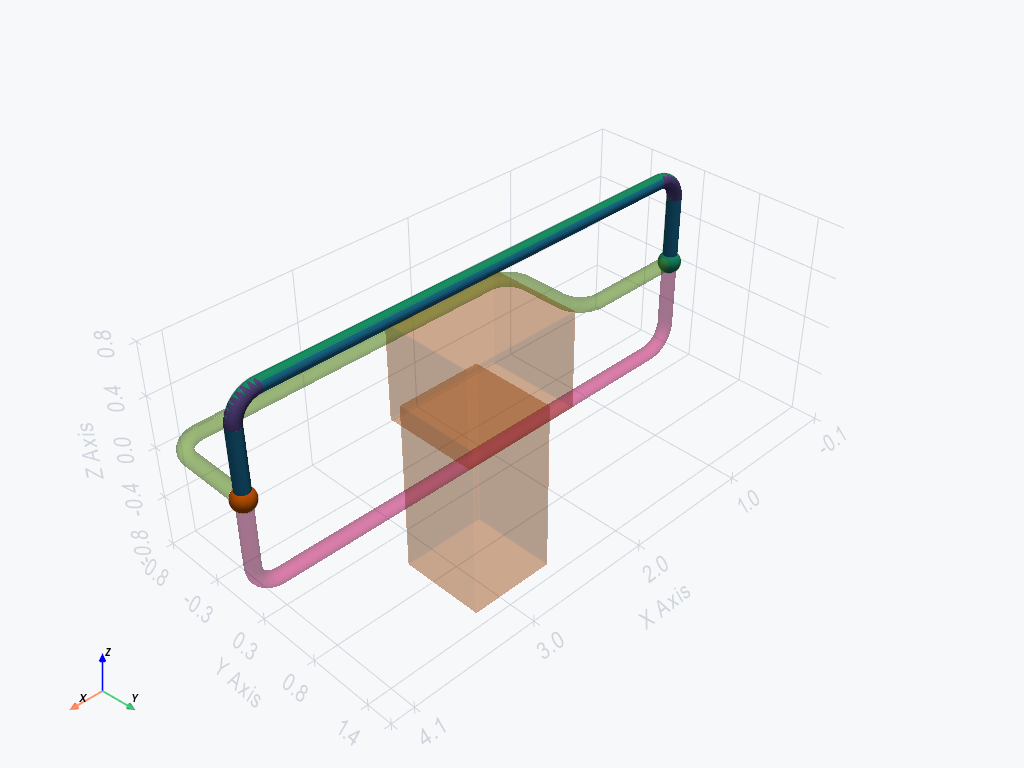

In [6]:
plotter = build_route_plotter(model, request=request, result=run.result)
plotter.show(jupyter_backend=JUPYTER_BACKEND)

## 6. Export Interactive HTML

Share the 3D route scene with colleagues who don't have Python installed.
`export_route_scene_html` writes a self-contained HTML file with embedded
WebGL rendering.


In [7]:
html_path = export_route_scene_html(
    model,
    "autoroute_scene.html",
    request=request,
    result=run.result,
)
print(f"Interactive route scene exported to: {html_path}")

Interactive route scene exported to: autoroute_scene.html


## 7. Review Generated Study Files

Because `export_study=True`, the agent writes Code_Aster input files for reviewed candidates.

| File | Purpose |
|---|---|
| `.comm` | Code_Aster command file |
| `.mail` | Mesh file with nodes, elements, and groups |
| `.export` | Job descriptor tying the study together |

These files are a solver handoff, not completed result visualization.


In [8]:
# ── List generated study files ────────────────────────────────────────
if OUTPUT_ROOT.exists():
    print(f"Study files in: {OUTPUT_ROOT}\n")
    for path in sorted(OUTPUT_ROOT.rglob("*")):
        if path.is_file():
            rel = path.relative_to(OUTPUT_ROOT)
            size_kb = path.stat().st_size / 1024
            print(f"  {rel}  ({size_kb:.1f} KB)")
else:
    print("No study files found — the solver config may have skipped export.")

Study files in: D:\Gitprojects\Tuba_v4\routing_reports\notebook_demo

  P-100\route_report.md  (1.0 KB)
  P-100\route_result.json  (9.8 KB)
  P-100\route_scene.html  (1166.9 KB)
  P-100\studies\P-100\candidate_0\study.comm  (4.4 KB)
  P-100\studies\P-100\candidate_0\study.export  (0.4 KB)
  P-100\studies\P-100\candidate_0\study.mail  (10.5 KB)
  P-100\studies\P-100\candidate_1\study.comm  (4.4 KB)
  P-100\studies\P-100\candidate_1\study.export  (0.4 KB)
  P-100\studies\P-100\candidate_1\study.mail  (10.5 KB)
  P-100\studies\P-100\candidate_2\study.comm  (4.7 KB)
  P-100\studies\P-100\candidate_2\study.export  (0.4 KB)
  P-100\studies\P-100\candidate_2\study.mail  (15.5 KB)


## Key Takeaways

| Concept | Detail |
|---|---|
| A-star pathfinding | Runs on a 3D occupancy grid built from model obstacles. |
| Obstacle avoidance | Each obstacle is inflated by the route clearance envelope. |
| Multiple candidates | Candidate count controls ranked route alternatives. |
| Code_Aster handoff | `.comm`, `.mail`, and `.export` files are generated per reviewed candidate. |

Next: `06_structural_frames_and_optimization.ipynb` adds structural racks and support optimization context.
